# Módulo 3: Transformación de características

## PCA




## Repaso de conceptos básicos 

PCA involucra conceptos de estadística y álgebra lineal, es imperativo revisar éstos antes de comenzar. 

In [1]:
import pandas as pd
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

plt.style.use('ggplot')

seed = 69

### Varianza 
La varianza es una medida que ya se ha platicado en este curso y que, aunque cuantifica la dispersión de los datos respecto de su media, no es directamente interpretable. 

La varianza de una variable se define como: 


$$
\sigma^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2
$$

Donde: 

$\bar{x}$: Promedio de los datos.


Se dice que no es directamente interpretable por la elevación al cuadrado, para interpretar usamos la _desviación estándar_ que la raíz cuadrada de la varianza. 


Leamos unos datos y veamos cómo se ve la varianza.

In [3]:
df = pd.read_csv('actividad_14,0.csv')


125161.880867369 246.31423580087215


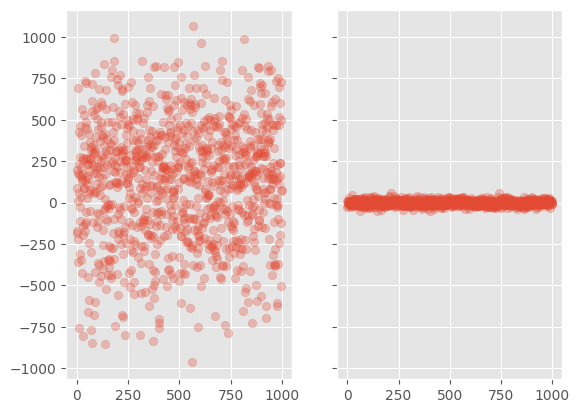

In [7]:
x = range(len(df))
y1 = df['x3'].values
y2 = df['x2'].values


varianza1 = np.var(y1)
varianza2 = np.var(y2)


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True)

ax1.scatter(x, y1, alpha=0.3)
ax2.scatter(x, y2, alpha=0.3)

print(varianza1, varianza2)

plt.show()

Visualmente confirmamos lo que el cálculo de la varianza nos dice: Hay mucha mayor dispersión en la primer variable comparada con la segunda.

### Covarianza
Cuando hablamos del concepto de varianza estamos hablando de una única variable. 

La covarianza es otra medida parecida, nos habla de la dependencia que existen entre dos variables. 

Algo importante resaltar es que al calcular la covarianza nos interesa más el signo, un signo **positivo** nos habla de una relación directa entre las variables mientras que uno **negativo** nos habla de relaciones indirectas. 

Se define como:

$$
Cov(X,Y) = \frac{1}{n}\sum_{i=1}^n (x_i - E[X])(y_i - E[Y])
$$

ó

$$
Cov(X,Y) = \frac{1}{2n^2}\sum_{i=1}^n \sum_{j=1}^n (x_i - x_j)(y_i - y_j)
$$
Donde (bajo ciertas condiciones):

$E[X]$ representa el promedio de la variable $x$.


Recordar que la versión _normalizada_ de la covarianza es la _correlación_ cuyo valor ya es interpretable. 

Veamos dos de nuestras variables: 

In [5]:
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,response
0,-60.304675,30.803830,-27.157777,198.975121,6.145247,-0.0,-558.196719,206.061854,44.604967,-636.910593,0
1,-73.829217,-32.512078,9.856376,-168.662567,-59.948577,-0.0,-479.510214,-122.454779,1.071665,83.729110,0
2,-83.741278,2.923676,-18.151317,-184.711546,-57.225943,-0.0,325.921200,-246.824508,-62.356931,168.007429,0
3,28.664602,-49.775246,9.593606,87.194568,119.446571,0.0,108.383142,-1004.036573,312.603866,23.830035,1
4,-41.764336,46.324575,-10.467802,9.220756,98.981305,-0.0,-924.770722,-560.583757,-140.590981,-220.214210,1


Calculemos la covarianza entre ambos: 

La diagonal de la matriz es la covarianza, nosotros tenemos que: 

$$
Cov(X, X) = Var(X)
$$

En las otras casillas observamos que el signo es negativo, se confirma que la relación entre ambas es inversa. 

### Eigenvectores / eigenvalores
El prefijo "eigen" viene del alemán y signifca "propio". 

Un vector propio o _eigenvector_ es tal que cumple con:

$$
Av = \lambda v 
$$

donde:

$A$: Matriz cuadrada de dimensiones $nxn$. 

$v$: Vector propio de $A$. 

$\lambda$: Valor propio, un número real o complejo.



Es posible observar por la ecuación anterior que el producto de la matriz $A$ por el vector propio $v$ es el mismo vector $v$ multiplicado por una constante (su valor propio $\lambda$).

Algunas propiedades interesantes son:

* Son ortogonales (perpendiculares) entre si. 
* Una matriz de $nxn$ tendrá $n$ vectores propios. 

Visualicemos cómo se verían los vectores propios en una matriz de 2x2.

Calculemos con ayuda de `numpy` los valores y vectores propios. 

Lo que nos arroja la función de numpy son los vectores estandarizados (con una magnitud de 1).

Estos se ven así: 

Podemos entonces terminar con los eigenvectores con el siguiente mensaje: 
    
Podemos expresar nuestros datos en términos de estos vectores orgotonales en lugar de expresarlos en términos de $x$ y $y$. 

Los vectores propios nos hablarán de una dirección, los valores propios nos hablarán de la magnitud.




### Proyección 
Hasta aquí, hemos cubierto lo más complicado del tema.

Es importante entender el concepto de proyección pues es finalmente lo que haremos con nuestros datos a través de los eigenvectores. 

Lo que nosotros queremos hacer es una proyección a través de los componentes principales, los eigenvectores.

En términos prácticos, queremos tomar las dimensiones que más nos expliquen sobre nuestro modelo. 

In [2]:
# Standard
copy = df[['x0', 'x1']].copy()
# copy_standard = (copy - copy.mean()) / copy.std()
medias = copy.mean()
copy_standard = copy - medias

# Cov
matriz = copy_standard.cov()

# Eigen
valores, vectores = np.linalg.eig(matriz)

# Plot original + Vectores
x = copy_standard.x0
y = copy_standard.x1
plt.scatter(x, y, alpha=0.2)

x = np.arange(-200, 200, 1)
plt.plot(x, (vectores[1, 0] / vectores[0, 0]) * x,
        color='blue', alpha=0.4,
         linestyle='--', label='Vector1') 
plt.plot(x, (vectores[1, 1] / vectores[0, 1]) * x,
        color='black', alpha=0.4,
         linestyle='--', label='Vector2')
plt.legend()
plt.title('Datos más vectores propios')
plt.show()

# Plot proyección al mejor vector
new = np.matrix(copy_standard) * np.matrix(vectores[:, 0]).T
regresada = new * vectores[:, 0] + np.array(medias)
plt.scatter(np.array(regresada[:, 0]),
            np.array(regresada[:, 1]), alpha=0.3)
plt.title('Proyección')
plt.show()

Lo que nosotros lograríamos con una proyección es poder llevar todos los datos hacia un eje, este eje es una nueva dimensión **y no una selección de variables** en la que visualizaremos nuestros datos.

## PCA

El análisis de componentes principales es una herramienta que nos ayuda a **reducir la dimensionalidad** de nuestro dataset.

Cada feature lo podemos entender como una dimensión, sin embargo, este método **no es un seleccionador de variables.**

Este método nos ayudará a proyectar nuestros datos hacia los ejes donde exista mayor _variabilidad_.

Cada eigenvalor (asociado a cada uno de los eigenvectores) está relacionado con cierta porción de la _variabilidad_ explicada (suma de distancias al cuadrado de cada punto a la línea en cuestión).


Para poder generar un PCA necesitamos:

* Identificar la distribución de nuestros datos.
* Remover la variable de respuesta del dataset a reducir.
* Estandarizar la data.
* Generar matriz de covarianzas / correlaciones. 
* Generar los $n$ eigenvectores de la matriz anterior.
* Escoger los $m$ (donde $m$ < $n$) vectores que nos ayuden a proyectar la data.
* Proyectar la data original  usando los primeros  $m$ vectores ordenados por su respectivo valor propio.

 

### Ejecutando paso a paso un PCA

#### 1. Identificar distribución de nuestros datos.

A simple vista y a falta de rigor estadístico, vemos que hay escalas muy diferentes entre nuestras variables. Normalizaremos.

#### 2. Remover response del dataset.
Buscamos encontrar explicabilidad entre nuestros features, no entre nuestra variable. 

#### 3. Estandarizar nuestra data

En el PCA "clásico" la data solo se centra, al estandarizar nosotros estaremos usando la matriz de correlaciones en lugar de la de covarianzas. 

Notamos que la variable 5 está llena de NaNs, esto por ser una constante. La removeremos. 

#### 4. Generar matriz de interacciones

#### 5. Generar vectores y valores propios

#### 6. Escoger los vectores adecuados

Dado a que cada vector tiene un valor asignado y que estamos buscando explicar la mayor variabilidad posible, aplicaremos el _elbow method_ para la elección de nuestros vectores previo a la proyección. 

In [3]:
# {Índice: Valor propio}


In [4]:
# Same pero con los vectores


Ahora, ordenaremos los valores propios de mayor a menor.

Consúltese código en: https://stackoverflow.com/questions/613183/how-do-i-sort-a-dictionary-by-value

Grafiquemos 

In [5]:
# Plot


En este problema podemos usar los primeros 6 eigenvectores (ordenados según la gráfica) para generar la proyección y finalmente tener un espacio de 1000x6 en lugar de 1000x10.

#### Proyectar la data 
Esto lo haremos con un poco de multiplicacion matricial.

Nuestra multiplicación de matrices se verá así:

$1000x9 \times 9x6$

Resultando en:
$1000x6$


#### Generemos modelos y comparemos

Por supuesto el performance es ligeramente menor en el modelo con la proyección, hay los siguientes puntos relevantes: 

* No es dramáticamente menor (para este set).
* Lo hicimos con 33% menos variables y solo dejamos ir el "20% de la información".

PCA entonces:

* Nos ayuda a reducir la dimensionalidad de un dataset.
* Especialmente útil cuando tenemos demasiadas columnas y queremos encontrar un espacio donde exista la mayor explicabilidad. 